In [23]:
from core import altopt, plot_altopt
from core import DataContext, ParameterContext
from core import get_final_interpolator, load_experiment, get_predictions_batch
import os
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

In [24]:
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10"

ilist = [2]#,1, 2,3]
for i in ilist:
    for j in range(0,2,2):
        # if i in [0,1]: #and j < 8:
        #    continue
        curr_time = 35.0 + j
        DATASET3 = DataContext(
            sim_time = os.path.join(DATA_DIR, "t_array.csv"),
            sim_freq = os.path.join(DATA_DIR, "delz_MHz.csv"),
        sim_by = os.path.join(DATA_DIR, "dely_MHz.csv"),
        sim_intensities = sorted([
            os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0_dely_") and f.endswith(".csv")
        ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0])),
        exp_time = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\t_array_ Copy.csv",
        exp_freq_axis = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_Y_MHz.csv",
        exp_data = f"DataFiles_to_Dinesh_Pranav\\Data_files\\Experiment\\26_03_2026_CW_data\\Bz_V_Readout_By_{i}.csv",
        save_path = f"Results\\Dataset_10\\05_June\\Frequentist\\Linear_Interpolation\\Test_{(j//2)}_Dataset_10_By_{i}_frequentist",
        interpolator=r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10\gpu_sim_interpolator_new_normalisation_linear_spline_0.3_threshold.npz",
        Sim_Aligned = True,
        Exp_Aligned = False,
        sim_pulse_thresh=0.3, 
        exp_pulse_thresh=0.3
        )
        DEFAULT_ALTOPT_PARAMS = ParameterContext(
            num_iter=10,
            curr_time = curr_time,
            max_time = 70.0,
            tol_bz=1e-20,
            tol_by=1e-20,
            t_step = 0.2,
            fixed_by_estimate=0.0,
            B_unk_bound_transverse_upper=0.4,
            fixed_bz_estimate=0.0,
            print_plot = False,
            Est_First_Z= False,
            likelihood_mode_longitudinal="Cauchy",
            likelihood_mode_transverse="Cauchy"
            )
        sign = "plus" if DEFAULT_ALTOPT_PARAMS.fixed_bz_estimate >= 0 else "minus"
        Test = r"Dataset_10_Starting with" + str(DEFAULT_ALTOPT_PARAMS.curr_time) + r" us_T Step " + str(DEFAULT_ALTOPT_PARAMS.t_step) + r" us_" + sign + r"_" + str(np.abs(DEFAULT_ALTOPT_PARAMS.fixed_bz_estimate)) + r"_initial estimate"
        save_path = sign + r"_" + str(np.abs(DEFAULT_ALTOPT_PARAMS.fixed_bz_estimate)) + r"_initial_estimate"
        DEFAULT_ALTOPT_PARAMS.Test = Test

Frequentist Benchmark

Firstly, we load the simulator and the file

In [25]:
t_sim, f_sim, by_sim, sim_spline = get_final_interpolator(DATASET3, DEFAULT_ALTOPT_PARAMS)
t_exp, f_bias_axis, exp_matrix = load_experiment(DATASET3, DATASET3.Exp_Aligned)

...Building Final Interpolator...
Time taken to load Interpolator: 2.659025192260742
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_V_Readout_By_2.csv...
  > Exp Start: -0.1100s
0.20721173286437988 was the time taken to load exp data.


(4376, 111) (111,)
4 0.9607250475267908
-0.0446259231987862
54


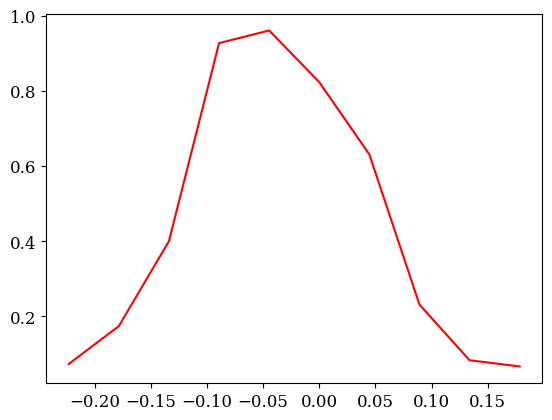

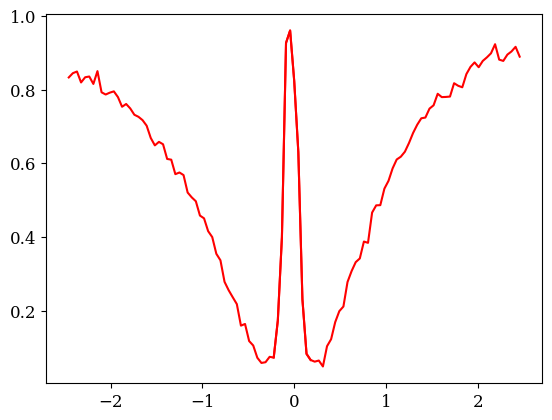

In [26]:
# t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)
exp_matrix_final_time = exp_matrix[-1,:]
print(exp_matrix.shape, exp_matrix_final_time.shape)
print(np.argmax(exp_matrix_final_time[50:60]), np.max(exp_matrix_final_time[50:60]))
print(f_bias_axis[50:60][np.argmax(exp_matrix_final_time[50:60])])
cpt_peak_loc = f_bias_axis[50:60][np.argmax(exp_matrix_final_time[50:60])]
print(np.where(f_bias_axis == cpt_peak_loc)[0][0])
plt.plot(f_bias_axis[50:60], exp_matrix_final_time[50:60], label="Experiment Final Time", color="red")
plt.show(0)
plt.plot(f_bias_axis, exp_matrix_final_time, label="Experiment Final Time", color="red")

So, now we simply add cpt_peak_loc, to recentre the axis to zero or we set Bz_unk = cpt_peak_loc

In [27]:
final_time = t_exp[-1]

In [28]:
sim_matrix_fixed_time = get_predictions_batch(sim_spline, final_time, f_sim, by_sim)
print(sim_matrix_fixed_time.shape)
print(by_sim[0])

0.0008261203765869141 was the time taken to compute the Interpolated Values.| (91, 51)
0.0


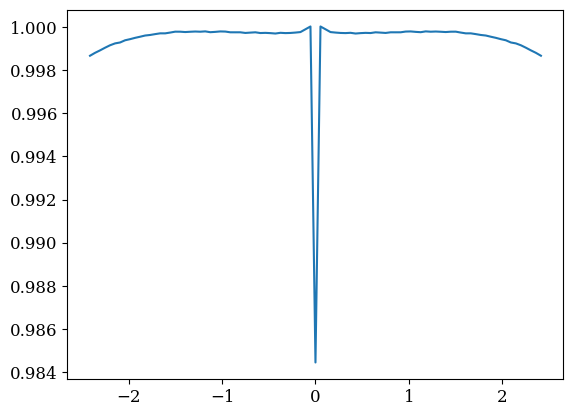

In [29]:
plt.plot(f_sim.get(), sim_matrix_fixed_time[:, 0].get())

Now construct a function for any given y value and any given x value interpolator; use perhaps some nice cubic spline interpolator

In [30]:
def f_y_interpolator(t_fixed, bz_query, bz_fixed, by):
    by = cp.asarray(by)
    t_fixed = cp.asarray(t_fixed)
    bz_query = cp.asarray(bz_query)
    bz_fixed = cp.asarray(bz_fixed)
    bz_query = bz_query + bz_fixed
    sim_matrix_fixed_time = get_predictions_batch(sim_spline, t_fixed, bz_query, by)
    print(sim_matrix_fixed_time.shape)
    if by.shape == ():
        return np.squeeze(sim_matrix_fixed_time.get())
    return sim_matrix_fixed_time.get()

Then construct a simple loss function for the final time slice

0.0015766620635986328 was the time taken to compute the Interpolated Values.| (111, 100)
(111,) (111, 100)
0.2878787878787879 1.580062041731177


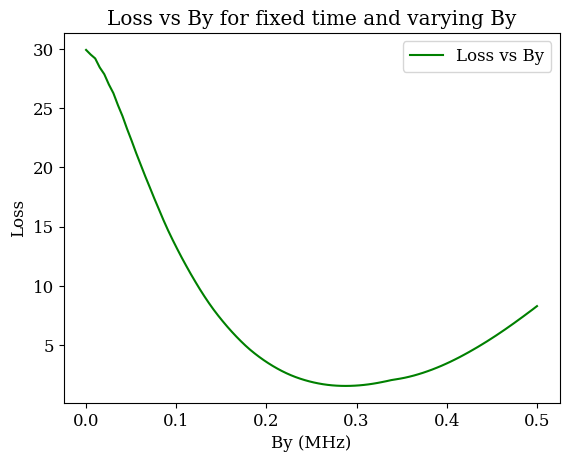

In [31]:
t_fixed = final_time
bz_query = f_bias_axis
by = np.linspace(0, 0.5, 100)

interpolated_values = f_y_interpolator(t_fixed, bz_query, -1*cpt_peak_loc, by)
print(exp_matrix_final_time.shape, interpolated_values.shape)

loss = np.sum((exp_matrix_final_time[:, None] - interpolated_values)**2, axis = 0)

print(by[np.argmin(loss)], np.min(loss))

plt.plot(by,loss, label="Loss vs By", color="green")
plt.legend()
plt.xlabel("By (MHz)")
plt.ylabel("Loss")
plt.title("Loss vs By for fixed time and varying By")
plt.show()

Now, lets move onto the curve fit for B_y

In [32]:
t_val = final_time              
bz_ambient_val = -1 * cpt_peak_loc       

xdata_bz_bias = f_bias_axis  
ydata_transmission = exp_matrix_final_time 

fit_wrapper = lambda x, p_by: f_y_interpolator(t_val, x, bz_ambient_val, p_by)

initial_guess = [0.1] 

lower_bounds = [0.0]
upper_bounds = [1.0]

popt, pcov = curve_fit(
    f=fit_wrapper, 
    xdata=xdata_bz_bias, 
    ydata=ydata_transmission, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds),
    diff_step = 1e-3,
    x_scale = 'jac',
    ftol = 1e-10,
    xtol = 1e-10,
    gtol = 1e-10
)

by_estimate = popt[0]
by_variance = pcov[0, 0]
by_standard_error = np.sqrt(by_variance)

print(f"Estimated By: {by_estimate:.5f} +/- {by_standard_error:.5f}")

0.0013651847839355469 was the time taken to compute the Interpolated Values.| (111,)
0.0011823177337646484 was the time taken to compute the Interpolated Values.| (111,)
0.0011546611785888672 was the time taken to compute the Interpolated Values.| (111,)
0.001096963882446289 was the time taken to compute the Interpolated Values.| (111,)
0.0013704299926757812 was the time taken to compute the Interpolated Values.| (111,)
0.0011773109436035156 was the time taken to compute the Interpolated Values.| (111,)
0.0011374950408935547 was the time taken to compute the Interpolated Values.| (111,)
0.0011906623840332031 was the time taken to compute the Interpolated Values.| (111,)
0.0005581378936767578 was the time taken to compute the Interpolated Values.| (111,)
0.0004971027374267578 was the time taken to compute the Interpolated Values.| (111,)
0.0004596710205078125 was the time taken to compute the Interpolated Values.| (111,)
0.0004627704620361328 was the time taken to compute the Interpolat

Now construct a function for a fixed y value, independent parameter as bias, and Bzunk as being the parameter to be estimated

In [33]:
def f_z_interpolator(t_fixed, bz_query, bz, by_fixed):
    by_fixed = cp.asarray(by_fixed)
    t_fixed = cp.asarray(t_fixed)
    bz_query = cp.asarray(bz_query)
    bz = cp.asarray(bz)
    if bz.shape == ():
        bz_query = bz_query + bz
    else:
        bz_query = bz_query[:, None] + bz[None, :]
    sim_matrix_fixed_time = get_predictions_batch(sim_spline, t_fixed, bz_query, by_fixed, mode = 'Longitudinal Likelihood Frequentist')
    print(sim_matrix_fixed_time.shape)
    if bz.shape == ():
        return np.squeeze(sim_matrix_fixed_time.get())
    return sim_matrix_fixed_time.get()

0.0005578994750976562 was the time taken to compute the Interpolated Values.| (111, 1000)
(111,) (111, 1000)
0.04304304304304303 1.580012159848391


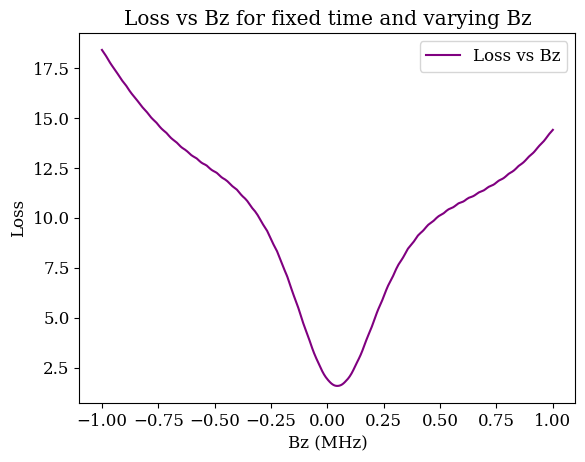

In [34]:
t_fixed = final_time
bz_query = f_bias_axis
by_fixed = by_estimate

bz = cp.linspace(-1, 1, 1000)

interpolated_values_z = f_z_interpolator(t_fixed, bz_query, bz, by_fixed)
print(exp_matrix_final_time.shape, interpolated_values_z.shape)

loss_z = np.sum((exp_matrix_final_time[:, None] - interpolated_values_z)**2, axis = 0)

print(bz[np.argmin(loss_z)], np.min(loss_z))

plt.plot(bz.get(), loss_z, label="Loss vs Bz", color="purple")
plt.legend()
plt.xlabel("Bz (MHz)")
plt.ylabel("Loss")
plt.title("Loss vs Bz for fixed time and varying Bz")
plt.show()


In [35]:
t_val = final_time              
by_ambient_val = by_estimate     

xdata_bz_bias = f_bias_axis  
ydata_transmission = exp_matrix_final_time 

fit_wrapper = lambda x, p_bz: f_z_interpolator(t_val, x, p_bz, by_ambient_val)

initial_guess = [0.1] 

lower_bounds = [-1.0]
upper_bounds = [1.0]

popt, pcov = curve_fit(
    f=fit_wrapper, 
    xdata=xdata_bz_bias, 
    ydata=ydata_transmission, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds),
    diff_step = 1e-3,
    x_scale = 'jac',
    ftol = 1e-10,
    xtol = 1e-10,
    gtol = 1e-10
)

bz_estimate = popt[0]
bz_variance = pcov[0, 0]
bz_standard_error = np.sqrt(bz_variance)

print(f"Estimated Bz: {bz_estimate:.5f} +/- {bz_standard_error:.5f}")

0.002130746841430664 was the time taken to compute the Interpolated Values.| (111,)
0.0005452632904052734 was the time taken to compute the Interpolated Values.| (111,)
0.0011975765228271484 was the time taken to compute the Interpolated Values.| (111,)
0.001196146011352539 was the time taken to compute the Interpolated Values.| (111,)
0.001201629638671875 was the time taken to compute the Interpolated Values.| (111,)
0.0011391639709472656 was the time taken to compute the Interpolated Values.| (111,)
0.0011548995971679688 was the time taken to compute the Interpolated Values.| (111,)
0.0010905265808105469 was the time taken to compute the Interpolated Values.| (111,)
0.0010869503021240234 was the time taken to compute the Interpolated Values.| (111,)
0.001085042953491211 was the time taken to compute the Interpolated Values.| (111,)
0.0011222362518310547 was the time taken to compute the Interpolated Values.| (111,)
0.001332998275756836 was the time taken to compute the Interpolated V

Now we should write a code for an alternating estimation procedure. How are we doing this?

0.0005176067352294922 was the time taken to compute the Interpolated Values.| (111,)
0.0010149478912353516 was the time taken to compute the Interpolated Values.| (111,)
0.0011186599731445312 was the time taken to compute the Interpolated Values.| (111,)
0.0009706020355224609 was the time taken to compute the Interpolated Values.| (111,)
0.0009467601776123047 was the time taken to compute the Interpolated Values.| (111,)
0.00048470497131347656 was the time taken to compute the Interpolated Values.| (111,)
0.00047779083251953125 was the time taken to compute the Interpolated Values.| (111,)
0.0004723072052001953 was the time taken to compute the Interpolated Values.| (111,)
0.0004456043243408203 was the time taken to compute the Interpolated Values.| (111,)
0.0004887580871582031 was the time taken to compute the Interpolated Values.| (111,)
0.0004932880401611328 was the time taken to compute the Interpolated Values.| (111,)
0.0005092620849609375 was the time taken to compute the Interpo

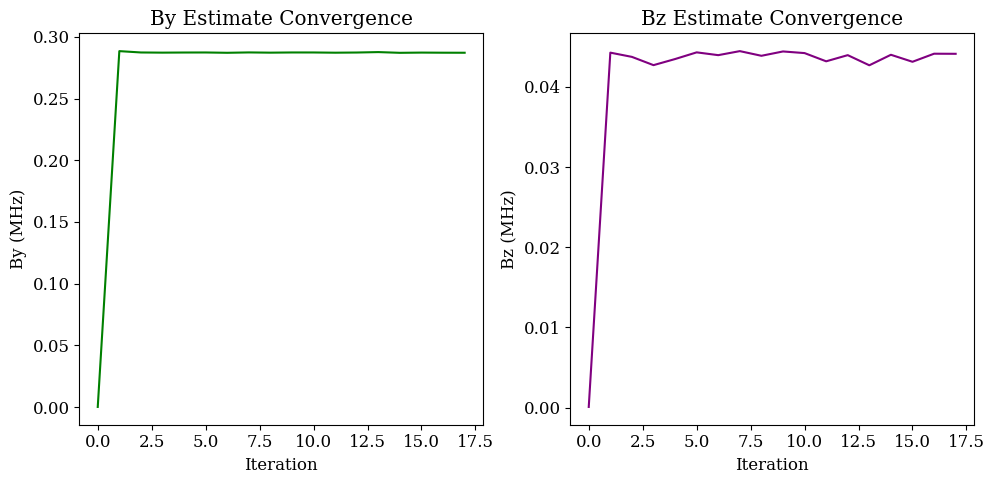

In [36]:
tol = 1e-4
t_val = final_time
By_0 = 1e-4
Bz_0 = 1e-4
curr_est = np.asarray([By_0, Bz_0])
old_est = np.asarray([0, 0])

bz_history = [curr_est[1]]
by_history = [curr_est[0]]

while np.linalg.norm(curr_est - old_est) > tol:
    old_est = curr_est.copy()
    #first y
    bz_ambient_val = curr_est[1]     

    xdata_bz_bias = f_bias_axis  
    ydata_transmission = exp_matrix_final_time 

    fit_wrapper = lambda x, p_by: f_y_interpolator(t_val, x, bz_ambient_val, p_by)

    initial_guess = [0.1] 

    lower_bounds = [0.0]
    upper_bounds = [1.0]

    popt, pcov = curve_fit(
        f=fit_wrapper, 
        xdata=xdata_bz_bias, 
        ydata=ydata_transmission, 
        p0=initial_guess, 
        bounds=(lower_bounds, upper_bounds),
        diff_step = 1e-3,
        x_scale = 'jac',
        ftol = 1e-10,
        xtol = 1e-10,
        gtol = 1e-10
    )

    curr_est[0] = popt[0]
    by_variance = pcov[0, 0]
    by_standard_error = np.sqrt(by_variance)


    #next z
    by_ambient_val = curr_est[0]     

    xdata_bz_bias = f_bias_axis  
    ydata_transmission = exp_matrix_final_time 

    fit_wrapper = lambda x, p_bz: f_z_interpolator(t_val, x, p_bz, by_ambient_val)

    initial_guess = [0.1] 

    lower_bounds = [-1.0]
    upper_bounds = [1.0]

    popt, pcov = curve_fit(
        f=fit_wrapper, 
        xdata=xdata_bz_bias, 
        ydata=ydata_transmission, 
        p0=initial_guess, 
        bounds=(lower_bounds, upper_bounds),
        diff_step = 1e-3,
        x_scale = 'jac',
        ftol = 1e-10,
        xtol = 1e-10,
        gtol = 1e-10
    )

    curr_est[1] = popt[0]
    bz_variance = pcov[0, 0]
    bz_standard_error = np.sqrt(bz_variance)
    bz_history.append(curr_est[1])
    by_history.append(curr_est[0])


print(bz_history[-1])
print(by_history[-1])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(len(by_history)), by_history, label="By Estimate", color="green")
plt.xlabel("Iteration")
plt.ylabel("By (MHz)")
plt.title("By Estimate Convergence")
plt.subplot(1,2,2)
plt.plot(range(len(bz_history)), bz_history, label="Bz Estimate", color="purple")
plt.xlabel("Iteration")
plt.ylabel("Bz (MHz)")  
plt.title("Bz Estimate Convergence")
plt.tight_layout()
plt.savepath = os.path.join(DATASET3.save_path, "By_Bz_Convergence.png")
plt.savefig(plt.savepath)
plt.show()

In [37]:
# Assuming t_val is your frozen time slice
def fit_joint_wrapper(xdata_bz_bias, bz_guess, by_guess):
    by_guess = cp.asarray(by_guess)
    t_fixed = cp.asarray(final_time)
    bz_query = cp.asarray(xdata_bz_bias)
    bz_guess = cp.asarray(bz_guess)
    if bz_guess.shape == ():
        bz_query = bz_query + bz_guess
    else:
        bz_query = bz_query[:, None] + bz_guess[None, :]
    sim_matrix_fixed_time = get_predictions_batch(sim_spline, t_fixed, bz_query, by_guess, mode = 'Longitdinal Likelihood Frequentist')
    print(sim_matrix_fixed_time.shape)
    if by_guess.shape == ():
        return np.squeeze(sim_matrix_fixed_time.get())
    return sim_matrix_fixed_time.get()

In [38]:
# Converged values from your ALS loop
p0_joint = [bz_history[-1], by_history[-1]] 

# Set bounds to encompass your simulation grid limits
bounds_joint = (
    [-1.0, 0], # Lower bounds for [Bz, By]
    [1.0, 0.5]  # Upper bounds for [Bz, By]
)

popt_joint, pcov_joint = curve_fit(
    f=fit_joint_wrapper,
    xdata=xdata_bz_bias,
    ydata=ydata_transmission,
    p0=p0_joint,
    bounds=bounds_joint,
    diff_step=1e-3,      # Crucial for grid interpolators
    x_scale='jac',       # Handles scale differences between Bz and By
    method='trf'
)

print(popt_joint)
print(pcov_joint)

0.0012288093566894531 was the time taken to compute the Interpolated Values.| (111,)
0.0008437633514404297 was the time taken to compute the Interpolated Values.| (111,)
0.0011322498321533203 was the time taken to compute the Interpolated Values.| (111,)
0.0010876655578613281 was the time taken to compute the Interpolated Values.| (111,)
0.001081228256225586 was the time taken to compute the Interpolated Values.| (111,)
0.0012781620025634766 was the time taken to compute the Interpolated Values.| (111,)
0.0010876655578613281 was the time taken to compute the Interpolated Values.| (111,)
0.0010955333709716797 was the time taken to compute the Interpolated Values.| (111,)
0.0010874271392822266 was the time taken to compute the Interpolated Values.| (111,)
0.0010814666748046875 was the time taken to compute the Interpolated Values.| (111,)
0.0010638236999511719 was the time taken to compute the Interpolated Values.| (111,)
0.0010685920715332031 was the time taken to compute the Interpolat

In [39]:
print(pcov_joint[0,1]/(np.sqrt(pcov_joint[0,0]) * np.sqrt(pcov_joint[1,1])))

0.03096561972045347


We are going to see if the transient data can resolve the field components effectively

In [40]:
i  = 3
j = 8
sigma_noise = 0.4
curr_time = 15.0 + j
prior = 1.0
directory = f"D:\\Pranav_and_Dinesh\\Dinesh\\Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_False\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Test_{j//2}_Dataset_10_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time_Sigma_noise_{sigma_noise}"
result_longitudinal_list = sorted([
    os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
result_transverse_list = sorted([
    os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))

# print(len(result_longitudinal_list))

longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]


time = transverse_field_estimation_results[8]["time"]
bias = transverse_field_estimation_results[8]["bias"]
time_1 = longitudinal_estimation_results[8]["time"]
bias_1 = longitudinal_estimation_results[8]["bias"]
print(len(time), len(bias))
print(len(time_1), len(bias_1))

251 251
240 240


We are going to do a NLLS with the time stamp.

In [41]:
t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)

In [42]:
MAX_TIME = 70.0
curr_time = time[0]
exp_data_to_compare = cp.array([])

t_sim_query = []
i = 0
while curr_time <= MAX_TIME:
    t_start = curr_time
    t_end = curr_time + 0.2
    curr_time += 0.2

    idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
    idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))
    bias_idx = cp.searchsorted(f_bias_axis, cp.asarray(bias[i]))
    exp_data_to_compare = cp.concatenate((exp_data_to_compare, exp_matrix[idx_start:idx_end, bias_idx]), axis=0)
    t_sim_query.append(t_exp[idx_start:idx_end].get())

    i+=1

MAX_TIME = 70.0
curr_time = time_1[0]
i = 0
while curr_time <= MAX_TIME:
    t_start = curr_time
    t_end = curr_time + 0.2
    curr_time += 0.2

    idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
    idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))
    bias_idx = cp.searchsorted(f_bias_axis, cp.asarray(bias_1[i]))
    exp_data_to_compare = cp.concatenate((exp_data_to_compare, exp_matrix[idx_start:idx_end, bias_idx]), axis=0)
    t_sim_query.append(t_exp[idx_start:idx_end].get())

    i+=1

2D Loss Landscape

In [43]:
def fitting_func_demo(bz_guess, by_guess):
    by_guess = cp.asarray(by_guess)
    bz_guess = cp.asarray(bz_guess)

    sim_matrix_to_compare = np.empty((0, bz_guess.shape[0], by_guess.shape[0]))
    curr_time = time[0]
    i=0
    while curr_time <= MAX_TIME:
        curr_bias = bias[i]
        bz_query = curr_bias + bz_guess
        i+=1

        t_start = curr_time
        t_end = curr_time + 0.2
        curr_time += 0.2

        idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
        idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))

        t_query = t_exp[idx_start:idx_end]
        sim_matrix_time_series = get_predictions_batch(sim_spline, t_query, bz_query, by_guess, mode = 'Time Series Frequentist')
        sim_matrix_time_series = sim_matrix_time_series.get()
        # print(sim_matrix_time_series.shape)
        sim_matrix_to_compare = np.concatenate((sim_matrix_to_compare, sim_matrix_time_series), axis=0)

    
    curr_time = time_1[0]
    i=0
    while curr_time <= MAX_TIME:
        curr_bias = bias_1[i]
        bz_query = curr_bias + bz_guess
        i+=1

        t_start = curr_time
        t_end = curr_time + 0.2
        curr_time += 0.2

        idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
        idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))

        t_query = t_exp[idx_start:idx_end]
        sim_matrix_time_series = get_predictions_batch(sim_spline, t_query, bz_query, by_guess, mode = 'Time Series Frequentist')
        sim_matrix_time_series = sim_matrix_time_series.get()
        # print(sim_matrix_time_series.shape)
        sim_matrix_to_compare = np.concatenate((sim_matrix_to_compare, sim_matrix_time_series), axis=0)
    
    
    return sim_matrix_to_compare

In [44]:
bz = cp.linspace(-1, 1, 200)
by = cp.linspace(0, 0.5, 200)

interpolated_values_demo = fitting_func_demo(bz, by)

print(interpolated_values_demo.shape, exp_data_to_compare.shape)

(6110, 200, 200) (6110,)


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_18688\2508764266.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Bz ($\mu T$)')
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_18688\2508764266.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('By ($\mu T$)')


Minimum Loss at Bz = 0.03517587939698494 MHz, By = 0.22613065326633167 MHz with Loss = 203.7405461517475


Text(0.5, 1.0, 'Loss Landscape Across Adaptive Trajectory')

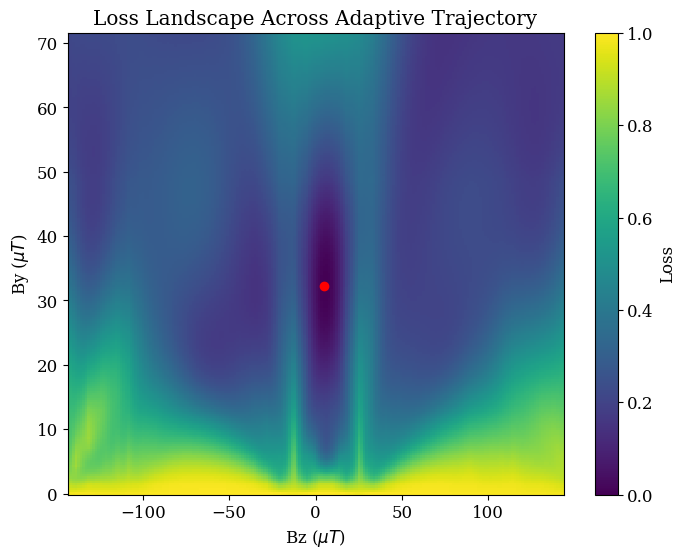

In [45]:
loss_demo = np.sum((exp_data_to_compare.get()[:, None, None] - interpolated_values_demo)**2, axis=0)

#to get coordinate of minimum loss
min_loss_idx = np.unravel_index(np.argmin(loss_demo), loss_demo.shape)
print("Minimum Loss at Bz =", bz[min_loss_idx[0]].get(), "MHz, By =", by[min_loss_idx[1]].get(), "MHz with Loss =", loss_demo[min_loss_idx])

plt.figure(figsize=(8,6))
plt.pcolormesh(bz.get() * 100 / 0.7, by.get() * 100 / 0.7, loss_demo.T, shading='auto', cmap='viridis')
plt.scatter(bz[min_loss_idx[0]].get() * 100 / 0.7, by[min_loss_idx[1]].get() * 100 / 0.7, color='red', label='Minimum Loss Point')
plt.colorbar(label='Loss')
plt.xlabel('Bz ($\mu T$)')
plt.ylabel('By ($\mu T$)')
plt.title("Loss Landscape Across Adaptive Trajectory")

2D NLLS

In [109]:

def fitting_func(xData,bz_guess, by_guess):
    by_guess = cp.asarray(by_guess)
    bz_guess = cp.asarray(bz_guess)

    sim_matrix_to_compare = np.array([])
    curr_time = time[0]
    i=0
    while curr_time <= MAX_TIME:
        curr_bias = bias[i]
        bz_query = curr_bias + bz_guess
        i+=1

        t_start = curr_time
        t_end = curr_time + 0.2
        curr_time += 0.2

        idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
        idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))

        t_query = t_exp[idx_start:idx_end]
        sim_matrix_time_series = get_predictions_batch(sim_spline, t_query, bz_query, by_guess, mode = 'Time Series Frequentist')
        sim_matrix_time_series = sim_matrix_time_series.get().flatten()
        # print(sim_matrix_time_series.shape)
        sim_matrix_to_compare = np.concatenate((sim_matrix_to_compare, sim_matrix_time_series), axis=0)
    
    curr_time = time_1[0]
    i=0
    while curr_time <= MAX_TIME:
        curr_bias = bias_1[i]
        bz_query = curr_bias + bz_guess
        i+=1

        t_start = curr_time
        t_end = curr_time + 0.2
        curr_time += 0.2

        idx_start = cp.searchsorted(t_exp, cp.asarray(t_start))
        idx_end = cp.searchsorted(t_exp, cp.asarray(t_end))

        t_query = t_exp[idx_start:idx_end]
        sim_matrix_time_series = get_predictions_batch(sim_spline, t_query, bz_query, by_guess, mode = 'Time Series Frequentist')
        sim_matrix_time_series = sim_matrix_time_series.get().flatten()
        # print(sim_matrix_time_series.shape)
        sim_matrix_to_compare = np.concatenate((sim_matrix_to_compare, sim_matrix_time_series), axis=0)
    
    return sim_matrix_to_compare

In [110]:
# Converged values from your ALS loop
p0_joint = [0.07, 0.1] 

# Set bounds to encompass your simulation grid limits
bounds_joint = (
    [-1.0, 0], # Lower bounds for [Bz, By]
    [1.0, 0.5]  # Upper bounds for [Bz, By]
)

popt_joint, pcov_joint = curve_fit(
    f=fitting_func,
    xdata=[],
    ydata=exp_data_to_compare.get(),
    p0=p0_joint,
    bounds=bounds_joint,
    diff_step=1e-3,      # Crucial for grid interpolators
    x_scale='jac',       # Handles scale differences between Bz and By
    method='trf'
)

print(popt_joint)
print(pcov_joint)

[0.03843974 0.2897529 ]
[[9.19105134e-07 6.66769420e-08]
 [6.66769420e-08 1.55086429e-06]]
